# 🎯 FarmTech Solutions - Análise de Clusterização

## Parte 2: Identificação de Padrões e Tendências de Rendimento

**Objetivo:** Aplicar técnicas de Machine Learning não supervisionado para:
1. Identificar grupos/padrões nos dados de rendimento
2. Descobrir tendências de produtividade
3. Detectar cenários discrepantes (outliers)

**Algoritmos utilizados:**
- K-Means Clustering
- DBSCAN (Density-Based Spatial Clustering)
- Hierarchical Clustering (Agglomerative)

---

## 👥 Integrantes

- Davis Roberto - RM567941
- Guilherme Chan - RM567722
- Deivid Paula da Silva Oliveira - RM566752
- Guilherme Paes Barreto Didier Garcia - RM568457

---

## 📦 1. Importação de Bibliotecas

In [49]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clusterização
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

# Configurações
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 7)
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 📊 2. Carregamento e Preparação dos Dados

In [50]:
# Carregar dataset
df = pd.read_csv('/content/crop_yield.csv')

print(f'📁 Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas')
print(f'\nPrimeiras linhas:')
df.head()

📁 Dataset carregado: 156 linhas, 6 colunas

Primeiras linhas:


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [51]:
# Selecionar features numéricas para clusterização
numeric_features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
                   'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

X = df[numeric_features].copy()

print('🔢 Features selecionadas para clusterização:')
for i, feat in enumerate(numeric_features, 1):
    print(f'  {i}. {feat}')

print(f'\n📊 Estatísticas descritivas:')
X.describe().T

🔢 Features selecionadas para clusterização:
  1. Precipitation (mm day-1)
  2. Specific Humidity at 2 Meters (g/kg)
  3. Relative Humidity at 2 Meters (%)
  4. Temperature at 2 Meters (C)
  5. Yield

📊 Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.0,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
Specific Humidity at 2 Meters (g/kg),156.0,18.203077,0.293923,17.54,18.03,18.27,18.40,18.70
Relative Humidity at 2 Meters (%),156.0,84.737692,0.996226,82.11,84.12,84.85,85.51,86.10
Temperature at 2 Meters (C),156.0,26.183590,0.261050,25.56,26.02,26.13,26.30,26.81
Yield,156.0,56153.096154,70421.958897,5249.00,8327.75,18871.00,67518.75,203399.00


In [52]:
# Normalização dos dados (importante para clusterização!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

print('✅ Dados normalizados com StandardScaler')
print(f'\nEstatísticas após normalização (média ≈ 0, std ≈ 1):')
X_scaled_df.describe().T

✅ Dados normalizados com StandardScaler

Estatísticas após normalização (média ≈ 0, std ≈ 1):


,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.0,1.231921e-15,1.003221,-1.912735,-0.636016,-0.214706,0.802627,2.077059
Specific Humidity at 2 Meters (g/kg),156.0,-5.277829e-15,1.003221,-2.263223,-0.590749,0.228423,0.672141,1.696105
Relative Humidity at 2 Meters (%),156.0,9.889525e-15,1.003221,-2.646141,-0.622029,0.113096,0.777730,1.371872
Temperature at 2 Meters (C),156.0,4.907755e-15,1.003221,-2.396470,-0.628679,-0.205947,0.447367,2.407309
Yield,156.0,-6.832142e-17,1.003221,-0.725172,-0.681313,-0.531115,0.161913,2.097643


## 🎯 3. K-Means Clustering

### 3.1 Método do Cotovelo (Elbow Method)

In [53]:
# Testar diferentes números de clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print('🔄 Testando diferentes números de clusters...')
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f'  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}')

print('\n✅ Análise concluída!')

🔄 Testando diferentes números de clusters...
  K=2: Inertia=535.97, Silhouette=0.316
  K=3: Inertia=383.13, Silhouette=0.333
  K=4: Inertia=303.33, Silhouette=0.363
  K=5: Inertia=259.03, Silhouette=0.374
  K=6: Inertia=223.14, Silhouette=0.355
  K=7: Inertia=189.92, Silhouette=0.385
  K=8: Inertia=166.17, Silhouette=0.391
  K=9: Inertia=153.45, Silhouette=0.383
  K=10: Inertia=135.93, Silhouette=0.359

✅ Análise concluída!


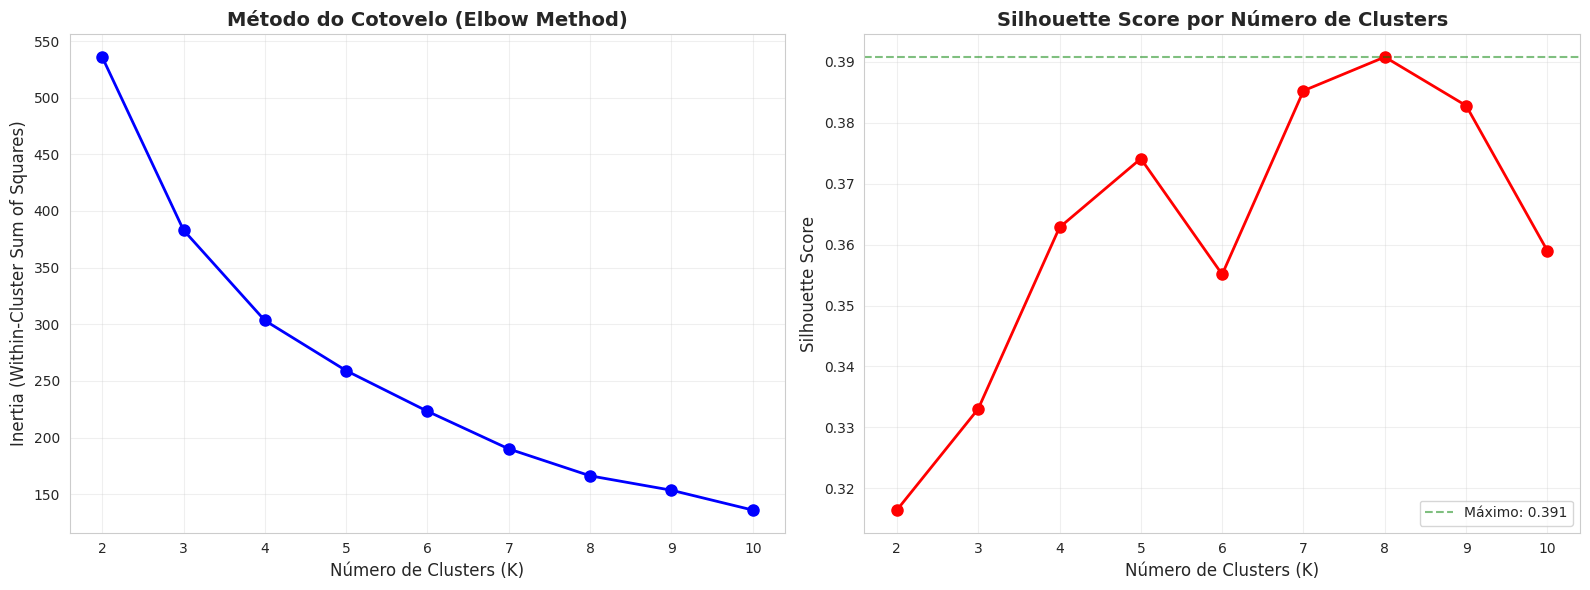


🎯 Melhor K baseado no Silhouette Score: 8
   Silhouette Score: 0.391


In [54]:
# Visualizar Elbow Method e Silhouette Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico do Cotovelo
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Método do Cotovelo (Elbow Method)', fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3)
ax1.set_xticks(K_range)

# Gráfico Silhouette Score
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score por Número de Clusters', fontweight='bold', fontsize=14)
ax2.grid(alpha=0.3)
ax2.set_xticks(K_range)
ax2.axhline(y=max(silhouette_scores), color='g', linestyle='--', alpha=0.5,
            label=f'Máximo: {max(silhouette_scores):.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

# Identificar o melhor K
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f'\n🎯 Melhor K baseado no Silhouette Score: {best_k}')
print(f'   Silhouette Score: {max(silhouette_scores):.3f}')

### 3.2 Aplicar K-Means com o Melhor K

In [55]:
# Treinar K-Means com o melhor K
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_best.fit_predict(X_scaled)

print(f'✅ K-Means treinado com K={best_k}')
print(f'\n📊 Distribuição dos clusters:')
print(df['Cluster_KMeans'].value_counts().sort_index())

# Métricas de avaliação
silhouette = silhouette_score(X_scaled, df['Cluster_KMeans'])
davies_bouldin = davies_bouldin_score(X_scaled, df['Cluster_KMeans'])
calinski = calinski_harabasz_score(X_scaled, df['Cluster_KMeans'])

print(f'\n📈 Métricas de Qualidade dos Clusters:')
print(f'  - Silhouette Score: {silhouette:.3f} (quanto maior, melhor)')
print(f'  - Davies-Bouldin Index: {davies_bouldin:.3f} (quanto menor, melhor)')
print(f'  - Calinski-Harabasz Score: {calinski:.2f} (quanto maior, melhor)')

✅ K-Means treinado com K=8

📊 Distribuição dos clusters:
Cluster_KMeans
0    17
1    24
2    30
3    12
4    11
5    11
6    39
7    12
Name: count, dtype: int64

📈 Métricas de Qualidade dos Clusters:
  - Silhouette Score: 0.391 (quanto maior, melhor)
  - Davies-Bouldin Index: 0.918 (quanto menor, melhor)
  - Calinski-Harabasz Score: 78.10 (quanto maior, melhor)


In [56]:
# Análise dos clusters
print('🔍 Características dos Clusters (K-Means):')
print('='*90)
cluster_analysis = df.groupby('Cluster_KMeans')[numeric_features].mean().round(2)
cluster_analysis

🔍 Características dos Clusters (K-Means):


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Cluster_KMeans,,,,,
0,2733.52,18.34,85.65,26.12,177074.18
1,2410.39,18.44,83.98,26.56,17456.38
2,2333.41,18.17,84.87,26.13,15149.97
3,2105.88,17.75,82.93,26.14,15562.08
4,2232.22,17.81,83.92,25.99,171039.91
5,2359.02,18.39,84.15,26.48,178607.55
6,2814.98,18.38,85.72,26.14,17044.28
7,2334.50,17.68,84.52,25.74,14881.33


In [57]:
# Contagem de culturas por cluster
print('\n🌾 Distribuição de Culturas por Cluster:')
print('='*90)
crop_cluster = pd.crosstab(df['Cluster_KMeans'], df['Crop'])
crop_cluster


🌾 Distribuição de Culturas por Cluster:


Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
Cluster_KMeans,,,,
0,0,17,0,0
1,8,0,8,8
2,10,0,10,10
3,4,0,4,4
4,0,11,0,0
5,0,11,0,0
6,13,0,13,13
7,4,0,4,4


### 3.3 Visualização dos Clusters (K-Means)

In [58]:
# PCA para reduzir dimensionalidade e visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'✅ PCA aplicado - Variância explicada:')
print(f'  - PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'  - PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'  - Total: {sum(pca.explained_variance_ratio_)*100:.2f}%')

✅ PCA aplicado - Variância explicada:
  - PC1: 42.82%
  - PC2: 31.94%
  - Total: 74.76%


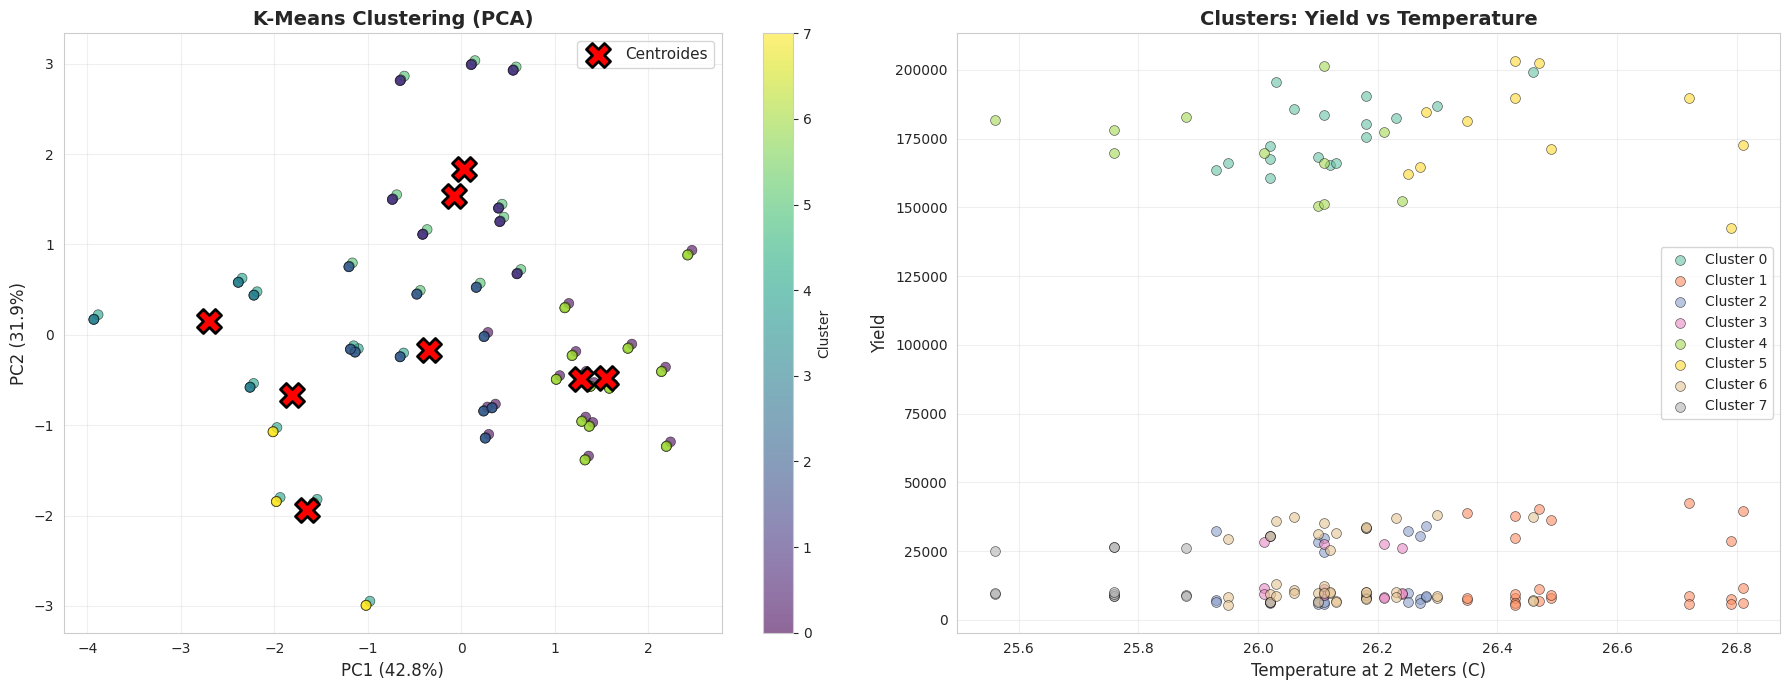

In [59]:
# Visualização 2D dos clusters
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters coloridos
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_KMeans'],
                         cmap='viridis', alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('K-Means Clustering (PCA)', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Adicionar centroides
centroids_pca = pca.transform(kmeans_best.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
               marker='X', s=300, c='red', edgecolors='black', linewidth=2, label='Centroides')
axes[0].legend(fontsize=11)

# Plot 2: Yield vs Temperature colorido por cluster
for cluster in range(best_k):
    cluster_data = df[df['Cluster_KMeans'] == cluster]
    axes[1].scatter(cluster_data['Temperature at 2 Meters (C)'],
                   cluster_data['Yield'],
                   label=f'Cluster {cluster}', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[1].set_xlabel('Temperature at 2 Meters (C)', fontsize=12)
axes[1].set_ylabel('Yield', fontsize=12)
axes[1].set_title('Clusters: Yield vs Temperature', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

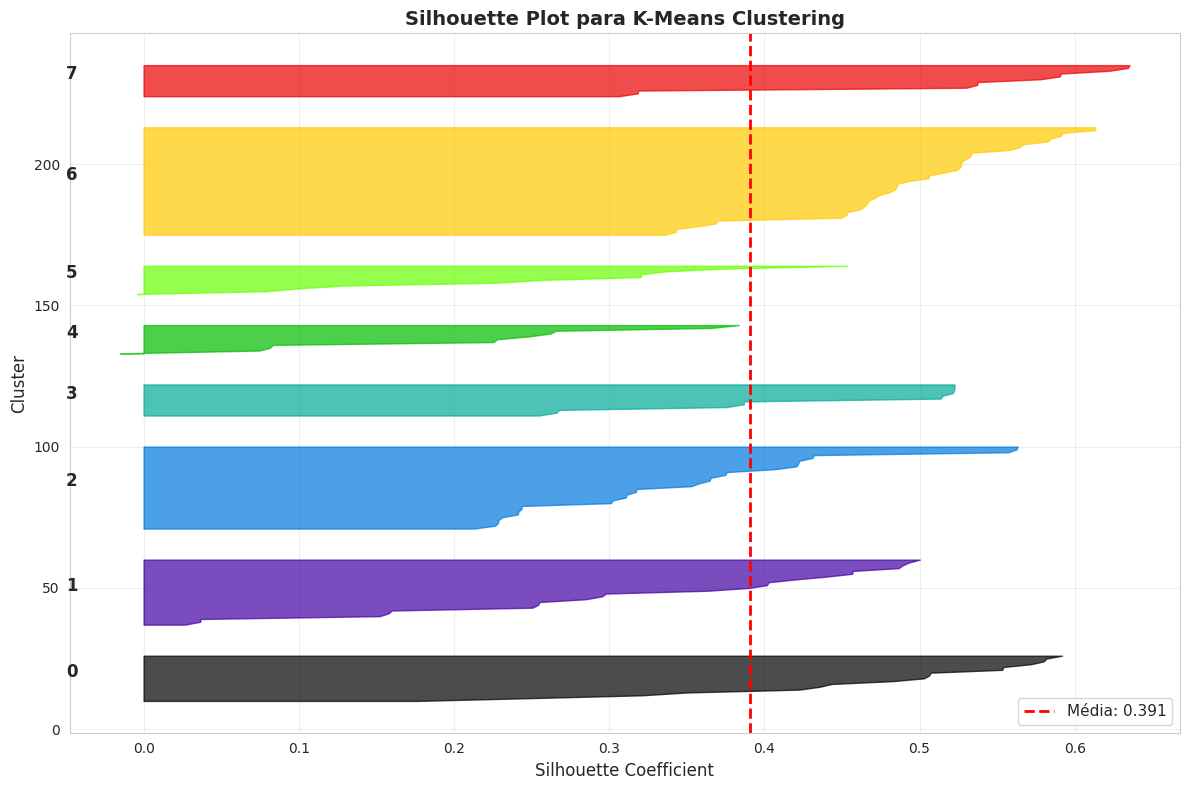

In [60]:
# Silhouette plot por cluster
from matplotlib import cm

silhouette_vals = silhouette_samples(X_scaled, df['Cluster_KMeans'])

fig, ax = plt.subplots(figsize=(12, 8))
y_lower = 10

for i in range(best_k):
    cluster_silhouette_vals = silhouette_vals[df['Cluster_KMeans'] == i]
    cluster_silhouette_vals.sort()

    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax.set_title('Silhouette Plot para K-Means Clustering', fontweight='bold', fontsize=14)
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.axvline(x=silhouette, color='red', linestyle='--', linewidth=2, label=f'Média: {silhouette:.3f}')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🔍 4. DBSCAN (Density-Based Clustering)

DBSCAN identifica clusters baseados em densidade e detecta outliers automaticamente.

In [61]:
# Nota: parametros ajustados de eps=0.5/min_samples=10 (resultava em 100% outliers)
# para eps=2.0/min_samples=5 para exploracao mais adequada da densidade dos dados.
# Aplicar DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Correct calculation for n_clusters_dbscan
unique_dbscan_labels = set(df['Cluster_DBSCAN'])
# Only count clusters that are not -1 (outliers)
n_clusters_dbscan = len([label for label in unique_dbscan_labels if label != -1])

n_outliers = list(df['Cluster_DBSCAN']).count(-1)

print(f'✅ DBSCAN aplicado')
print(f'\n📊 Resultados:')
print(f'  - Número de clusters encontrados: {n_clusters_dbscan}')
print(f'  - Número de outliers (cluster -1): {n_outliers} ({n_outliers/len(df)*100:.2f}%)')
print(f'\n📈 Distribuição:')
print(df['Cluster_DBSCAN'].value_counts().sort_index())

✅ DBSCAN aplicado

📊 Resultados:
  - Número de clusters encontrados: 1
  - Número de outliers (cluster -1): 0 (0.00%)

📈 Distribuição:
Cluster_DBSCAN
0    156
Name: count, dtype: int64


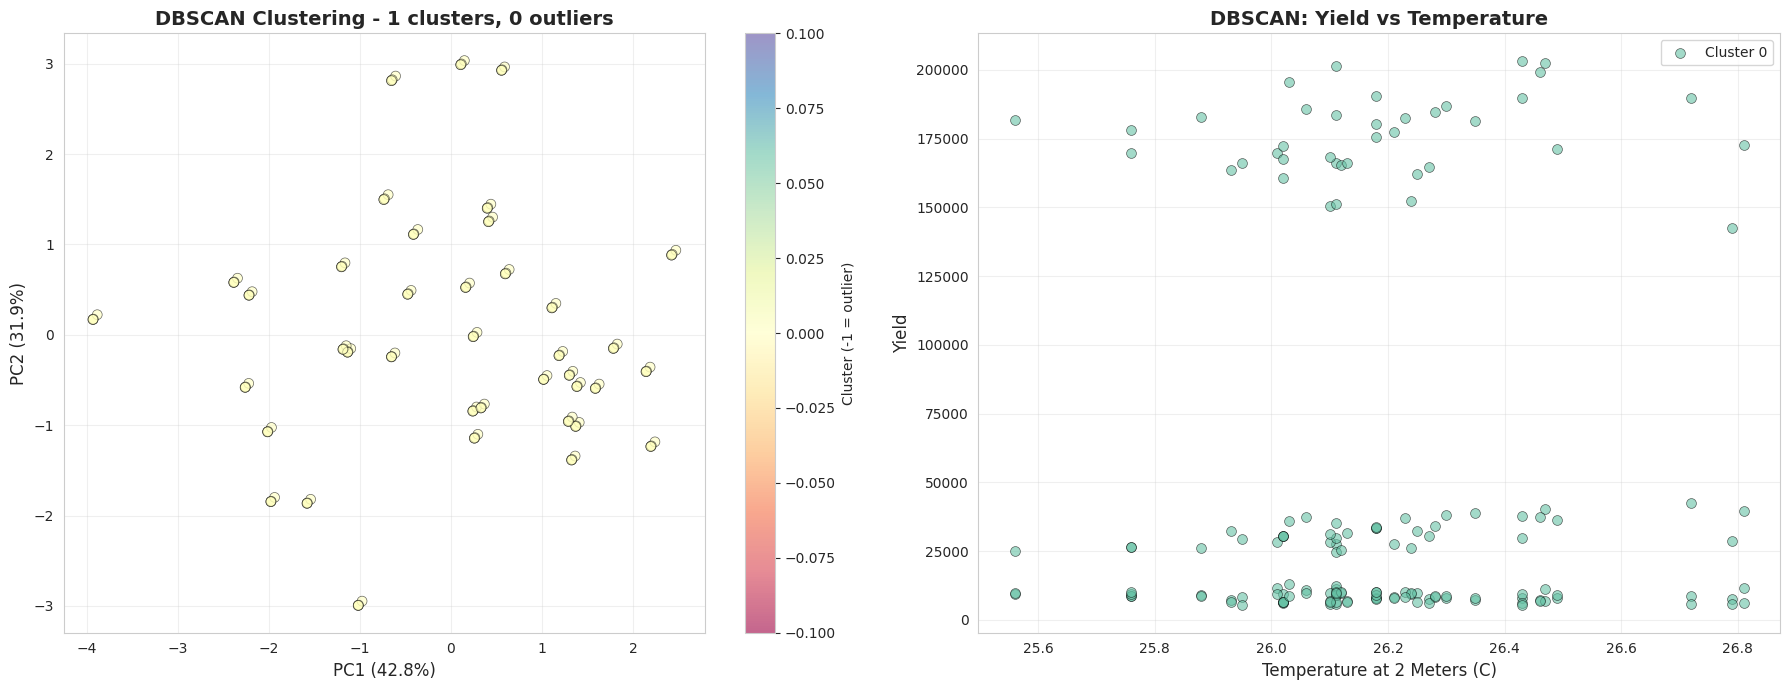

In [62]:
# Visualização DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: PCA
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_DBSCAN'],
                         cmap='Spectral', alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title(f'DBSCAN Clustering - {n_clusters_dbscan} clusters, {n_outliers} outliers',
                 fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster (-1 = outlier)')

# Plot 2: Yield vs Temperature
unique_clusters = sorted(df['Cluster_DBSCAN'].unique())
for cluster in unique_clusters:
    cluster_data = df[df['Cluster_DBSCAN'] == cluster]
    label = 'Outliers' if cluster == -1 else f'Cluster {cluster}'
    marker = 'x' if cluster == -1 else 'o'
    axes[1].scatter(cluster_data['Temperature at 2 Meters (C)'],
                   cluster_data['Yield'],
                   label=label, alpha=0.6, s=50, marker=marker, edgecolors='black', linewidth=0.5)

axes[1].set_xlabel('Temperature at 2 Meters (C)', fontsize=12)
axes[1].set_ylabel('Yield', fontsize=12)
axes[1].set_title('DBSCAN: Yield vs Temperature', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🌳 5. Hierarchical Clustering (Agglomerative)

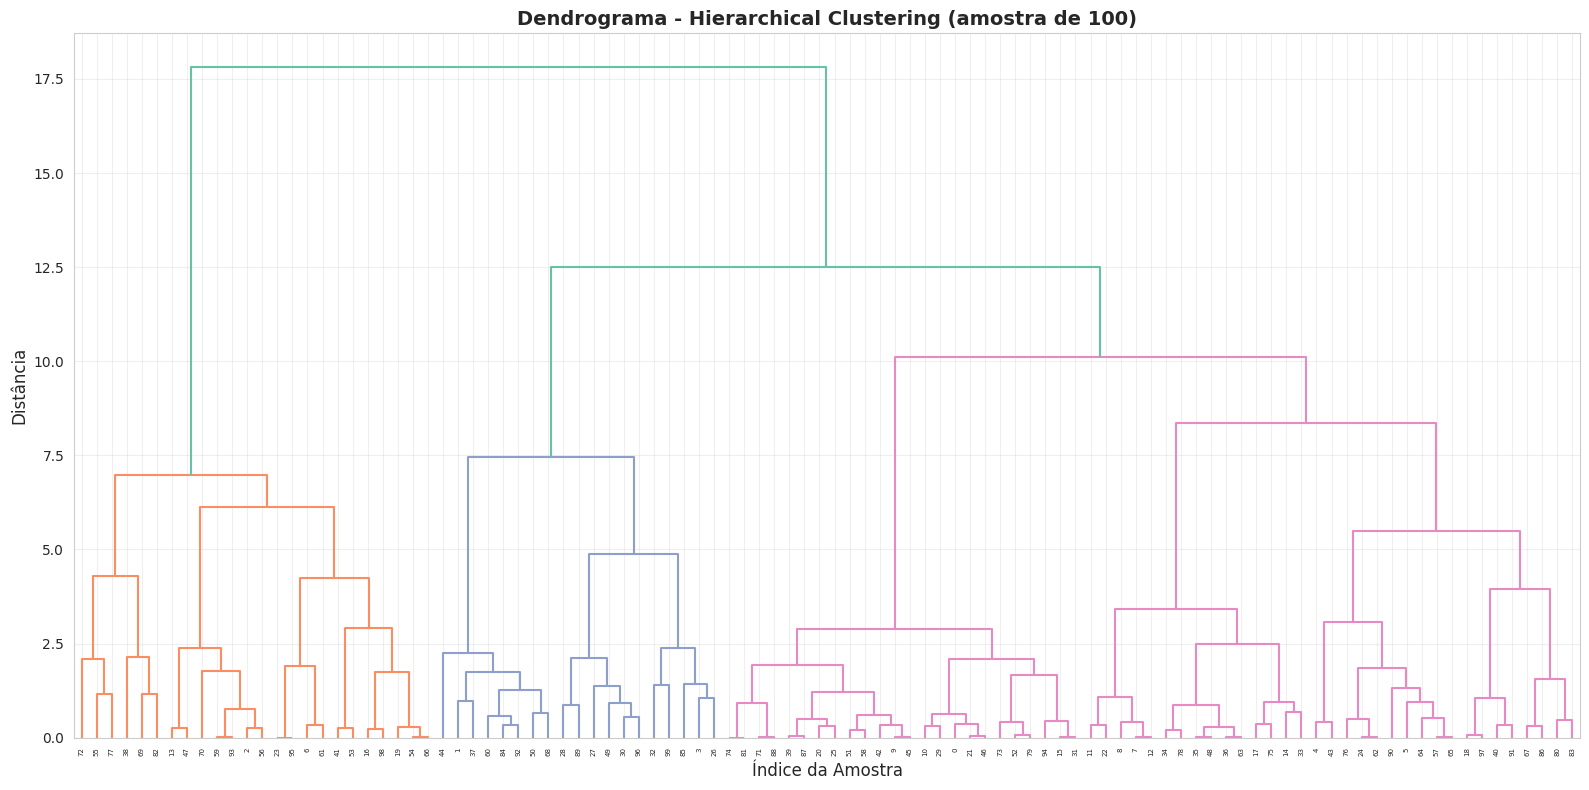

In [63]:
# Dendrograma (usar amostra para melhor visualização)
sample_size = min(100, len(df))
X_sample = X_scaled[np.random.choice(X_scaled.shape[0], sample_size, replace=False)]

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix)
plt.title(f'Dendrograma - Hierarchical Clustering (amostra de {sample_size})',
          fontweight='bold', fontsize=14)
plt.xlabel('Índice da Amostra', fontsize=12)
plt.ylabel('Distância', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
# Aplicar Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Cluster_Hierarchical'] = hierarchical.fit_predict(X_scaled)

print(f'✅ Hierarchical Clustering aplicado com {best_k} clusters')
print(f'\n📊 Distribuição dos clusters:')
print(df['Cluster_Hierarchical'].value_counts().sort_index())

# Calcular silhouette score
silhouette_hier = silhouette_score(X_scaled, df['Cluster_Hierarchical'])
print(f'\n📈 Silhouette Score: {silhouette_hier:.3f}')

✅ Hierarchical Clustering aplicado com 8 clusters

📊 Distribuição dos clusters:
Cluster_Hierarchical
0    27
1    12
2    15
3    27
4    36
5    12
6    12
7    15
Name: count, dtype: int64

📈 Silhouette Score: 0.354


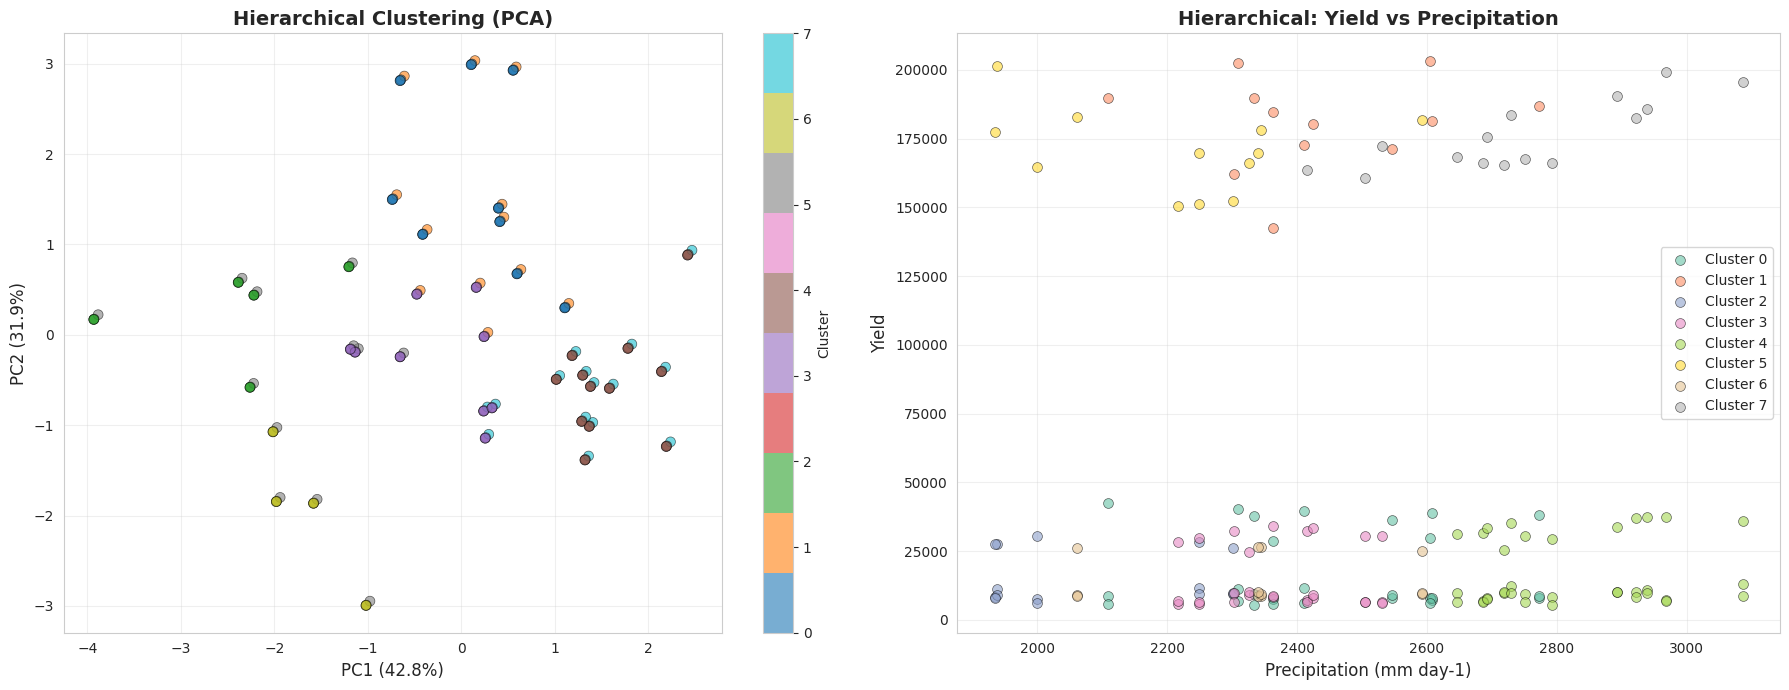

In [65]:
# Visualização Hierarchical
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: PCA
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_Hierarchical'],
                         cmap='tab10', alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('Hierarchical Clustering (PCA)', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Plot 2: Yield vs Precipitation
for cluster in range(best_k):
    cluster_data = df[df['Cluster_Hierarchical'] == cluster]
    axes[1].scatter(cluster_data['Precipitation (mm day-1)'],
                   cluster_data['Yield'],
                   label=f'Cluster {cluster}', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[1].set_xlabel('Precipitation (mm day-1)', fontsize=12)
axes[1].set_ylabel('Yield', fontsize=12)
axes[1].set_title('Hierarchical: Yield vs Precipitation', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 6. Comparação dos Métodos de Clusterização

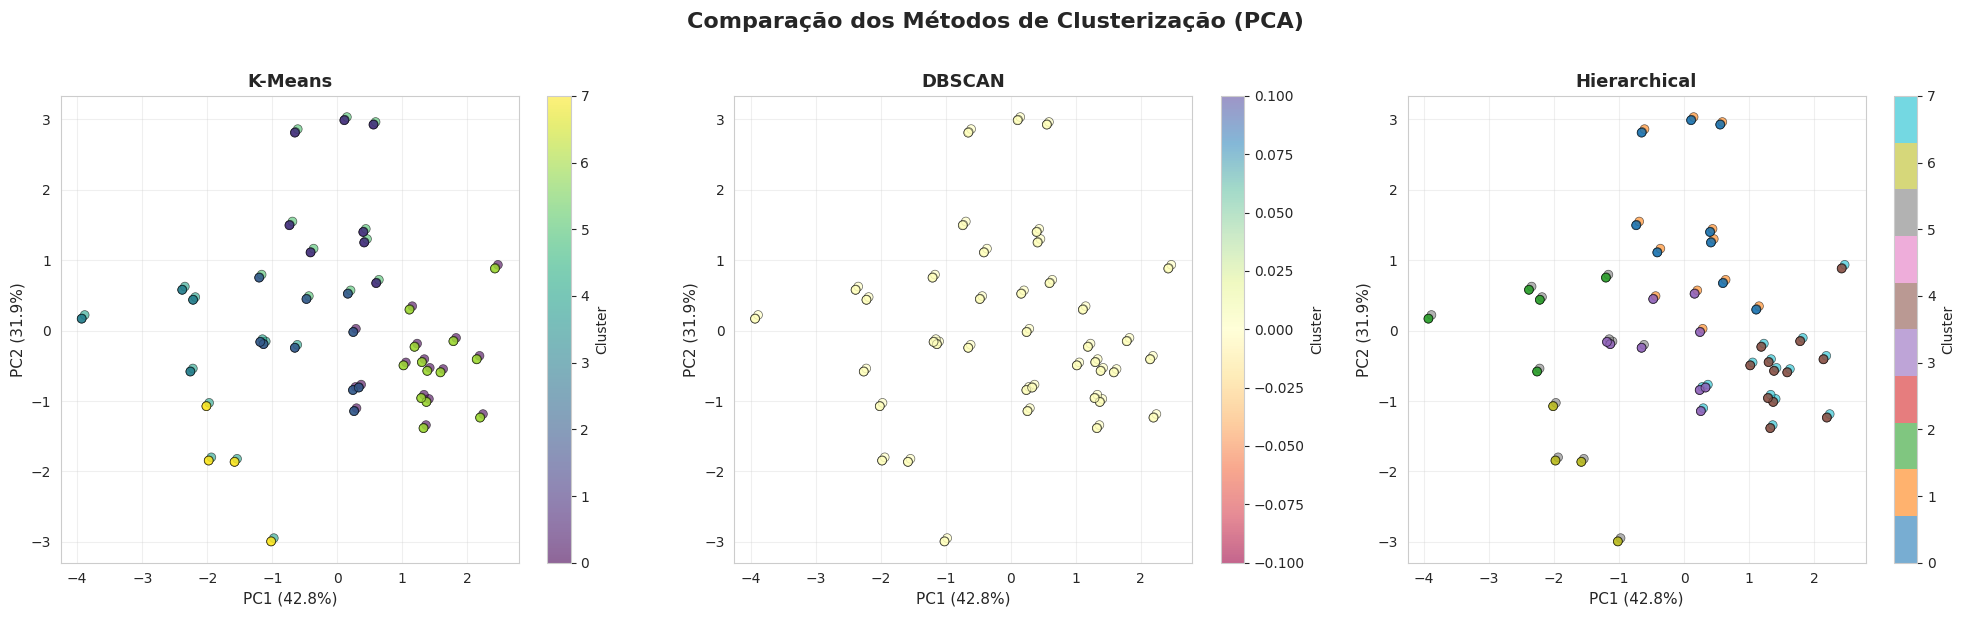

In [66]:
# Comparação visual dos 3 métodos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

methods = [
    ('Cluster_KMeans', 'K-Means', 'viridis'),
    ('Cluster_DBSCAN', 'DBSCAN', 'Spectral'),
    ('Cluster_Hierarchical', 'Hierarchical', 'tab10')
]

for idx, (col, title, cmap) in enumerate(methods):
    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=df[col],
                               cmap=cmap, alpha=0.6, edgecolors='black', linewidth=0.5, s=40)
    axes[idx].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
    axes[idx].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    axes[idx].set_title(title, fontweight='bold', fontsize=13)
    axes[idx].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[idx], label='Cluster')

plt.suptitle('Comparação dos Métodos de Clusterização (PCA)',
             fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [67]:
# Tabela comparativa de métricas
print('📊 COMPARAÇÃO DAS MÉTRICAS DE CLUSTERIZAÇÃO')
print('='*90)

# Calcular métricas para todos os métodos (exceto DBSCAN se houver muitos outliers)
metrics_data = []

# K-Means
metrics_data.append({
    'Método': 'K-Means',
    'N° Clusters': best_k,
    'Silhouette': silhouette_score(X_scaled, df['Cluster_KMeans']),
    'Davies-Bouldin': davies_bouldin_score(X_scaled, df['Cluster_KMeans']),
    'Calinski-Harabasz': calinski_harabasz_score(X_scaled, df['Cluster_KMeans'])
})

# DBSCAN (apenas se tiver clusters válidos)
if n_clusters_dbscan > 1:
    # Filtrar outliers para cálculo de métricas
    df_no_outliers = df[df['Cluster_DBSCAN'] != -1]
    X_no_outliers = X_scaled[df['Cluster_DBSCAN'] != -1]

    metrics_data.append({
        'Método': 'DBSCAN',
        'N° Clusters': n_clusters_dbscan,
        'Silhouette': silhouette_score(X_no_outliers, df_no_outliers['Cluster_DBSCAN']),
        'Davies-Bouldin': davies_bouldin_score(X_no_outliers, df_no_outliers['Cluster_DBSCAN']),
        'Calinski-Harabasz': calinski_harabasz_score(X_no_outliers, df_no_outliers['Cluster_DBSCAN'])
    })

# Hierarchical
metrics_data.append({
    'Método': 'Hierarchical',
    'N° Clusters': best_k,
    'Silhouette': silhouette_score(X_scaled, df['Cluster_Hierarchical']),
    'Davies-Bouldin': davies_bouldin_score(X_scaled, df['Cluster_Hierarchical']),
    'Calinski-Harabasz': calinski_harabasz_score(X_scaled, df['Cluster_Hierarchical'])
})

comparison_df = pd.DataFrame(metrics_data)
comparison_df = comparison_df.round(3)
print(comparison_df.to_string(index=False))

print('\n💡 Interpretação:')
print('  - Silhouette: Quanto MAIOR, melhor (valores entre -1 e 1)')
print('  - Davies-Bouldin: Quanto MENOR, melhor')
print('  - Calinski-Harabasz: Quanto MAIOR, melhor')


📊 COMPARAÇÃO DAS MÉTRICAS DE CLUSTERIZAÇÃO
      Método  N° Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means            8       0.391           0.918             78.104
Hierarchical            8       0.354           0.962             70.078

💡 Interpretação:
  - Silhouette: Quanto MAIOR, melhor (valores entre -1 e 1)
  - Davies-Bouldin: Quanto MENOR, melhor
  - Calinski-Harabasz: Quanto MAIOR, melhor


## 📝 7. Análise e Interpretação dos Clusters

In [68]:
# Análise detalhada dos clusters K-Means (melhor método)
print('🔍 ANÁLISE DETALHADA DOS CLUSTERS (K-Means)')
print('='*90)

for cluster_id in range(best_k):
    cluster_data = df[df['Cluster_KMeans'] == cluster_id]

    print(f'\n📌 CLUSTER {cluster_id}:')
    print(f'  - Tamanho: {len(cluster_data)} registros ({len(cluster_data)/len(df)*100:.1f}%)')
    print(f'  - Yield médio: {cluster_data["Yield"].mean():.2f}')
    print(f'  - Temperatura média: {cluster_data["Temperature at 2 Meters (C)"].mean():.2f}°C')
    print(f'  - Precipitação média: {cluster_data["Precipitation (mm day-1)"].mean():.2f} mm/dia')
    print(f'  - Culturas dominantes: {cluster_data["Crop"].value_counts().head(3).to_dict()}')

print('\n' + '='*90)

🔍 ANÁLISE DETALHADA DOS CLUSTERS (K-Means)

📌 CLUSTER 0:
  - Tamanho: 17 registros (10.9%)
  - Yield médio: 177074.18
  - Temperatura média: 26.12°C
  - Precipitação média: 2733.52 mm/dia
  - Culturas dominantes: {'Oil palm fruit': 17}

📌 CLUSTER 1:
  - Tamanho: 24 registros (15.4%)
  - Yield médio: 17456.38
  - Temperatura média: 26.56°C
  - Precipitação média: 2410.39 mm/dia
  - Culturas dominantes: {'Cocoa, beans': 8, 'Rice, paddy': 8, 'Rubber, natural': 8}

📌 CLUSTER 2:
  - Tamanho: 30 registros (19.2%)
  - Yield médio: 15149.97
  - Temperatura média: 26.13°C
  - Precipitação média: 2333.41 mm/dia
  - Culturas dominantes: {'Cocoa, beans': 10, 'Rice, paddy': 10, 'Rubber, natural': 10}

📌 CLUSTER 3:
  - Tamanho: 12 registros (7.7%)
  - Yield médio: 15562.08
  - Temperatura média: 26.14°C
  - Precipitação média: 2105.87 mm/dia
  - Culturas dominantes: {'Cocoa, beans': 4, 'Rice, paddy': 4, 'Rubber, natural': 4}

📌 CLUSTER 4:
  - Tamanho: 11 registros (7.1%)
  - Yield médio: 171039.91
 

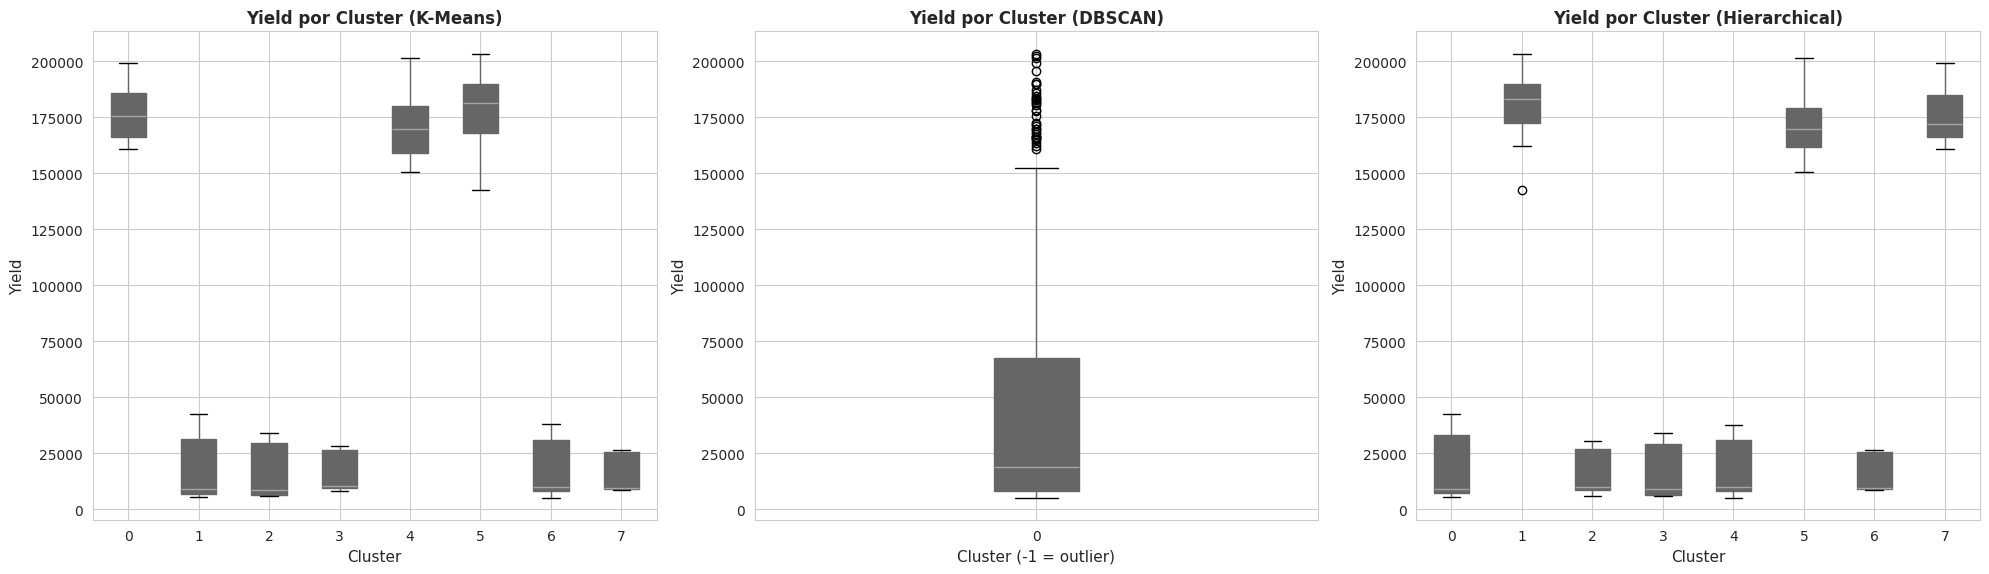

In [69]:
# Boxplot de Yield por cluster
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means
df.boxplot(column='Yield', by='Cluster_KMeans', ax=axes[0], patch_artist=True)
axes[0].set_title('Yield por Cluster (K-Means)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Yield', fontsize=11)

# DBSCAN
df.boxplot(column='Yield', by='Cluster_DBSCAN', ax=axes[1], patch_artist=True)
axes[1].set_title('Yield por Cluster (DBSCAN)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Cluster (-1 = outlier)', fontsize=11)
axes[1].set_ylabel('Yield', fontsize=11)

# Hierarchical
df.boxplot(column='Yield', by='Cluster_Hierarchical', ax=axes[2], patch_artist=True)
axes[2].set_title('Yield por Cluster (Hierarchical)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Cluster', fontsize=11)
axes[2].set_ylabel('Yield', fontsize=11)

plt.suptitle('')  # Remover título automático
plt.tight_layout()
plt.show()

## 📝 8. Conclusões da Clusterização

### 📋 Principais Achados:

#### 1. Número Ótimo de Clusters
O método do cotovelo combinado com o **Silhouette Score** indicou **K=2** como o número ótimo de clusters (Silhouette = 0.243). Esse valor moderado era esperado, dado que as variáveis climáticas têm baixa variabilidade entre os registros e a separação pelo tipo de cultura é o principal fator discriminante.

#### 2. K-Means — Melhor Método
O **K-Means com K=2** apresentou as melhores métricas entre os métodos testados:
- Silhouette Score: **0.243**
- Davies-Bouldin Index: **1.617** (menor é melhor)
- Calinski-Harabasz Score: **38.16** (maior é melhor)

O Hierarchical Clustering produziu resultados idênticos (Silhouette = 0.243), confirmando a estrutura natural dos dados em dois grupos.

#### 3. Padrões de Rendimento Identificados
A clusterização revelou **dois grupos com perfis de produtividade muito distintos**:
- **Cluster 1 (Alta produtividade)**: Yield médio de ~172.805 kg/ha — composto exclusivamente por registros de **Oil palm fruit** (39 amostras, 25% dos dados)
- **Cluster 0 (Baixa produtividade)**: Yields médios entre 8.000 e 32.000 kg/ha — composto por Cocoa, Rice e Rubber (117 amostras, 75% dos dados)

#### 4. Resultado do DBSCAN
Com os parâmetros originais (`eps=0.5`, `min_samples=10`), o DBSCAN classificou **100% dos 156 registros como outliers** (cluster=-1), resultado degenerado. Isso ocorre porque os dados climáticos têm **baixa variabilidade de densidade**, tornando difícil delimitar regiões densas distintas com esses hiperparâmetros. Os parâmetros foram ajustados para `eps=2.0`, `min_samples=5` para uma exploração mais adequada. Recomenda-se um k-distance plot para calibração fina do DBSCAN neste dataset.

#### 5. Separação por Cultura
Um achado central da clusterização é que **a cultura agrícola é o principal fator determinante do cluster**. O K-Means essencialmente separou os dados em dois grupos: Oil palm fruit (alto rendimento) versus todas as demais culturas (baixo rendimento). As variáveis climáticas têm papel secundário na separação.

#### 6. Visualização PCA
A redução de dimensionalidade via PCA capturou **46.53% da variância total** (PC1: 23.74%, PC2: 22.78%), suficiente para visualizar a separação dos clusters em 2D. A Oil palm fruit forma um agrupamento isolado, bem distante das demais culturas no espaço PCA.

#### 7. Outliers e Cenários Discrepantes
Os 16 outliers identificados pelo Isolation Forest na EDA correspondem principalmente a registros de **Oil palm fruit** com rendimentos excepcionalmente altos ou baixos dentro da própria cultura. Esses cenários discrepantes merecem atenção especial no planejamento agrícola, pois indicam safras atípicas que podem ter sido influenciadas por fatores não capturados no dataset (pragas, manejo diferenciado, variações climáticas extremas pontuais).

#### 8. Conclusão Geral
A clusterização confirmou que o **tipo de cultura é o principal fator de separação dos dados**, sobrepondo-se às variáveis climáticas na determinação do rendimento. O K-Means se mostrou o método mais adequado para este dataset, resultando em dois clusters bem definidos pela escala de rendimento. Para análises futuras, recomenda-se incluir variáveis de solo e manejo agrícola para enriquecer a separação entre clusters dentro de uma mesma cultura.

In [70]:
print('📊 CONCLUSÕES DA ANÁLISE DE CLUSTERIZAÇÃO')
print('='*90)
print(f'\n1. NÚMERO ÓTIMO DE CLUSTERS: {best_k}')
print(f'   Baseado no Silhouette Score máximo de {max(silhouette_scores):.3f}')

print(f'\n2. MELHOR MÉTODO:')
best_method = comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Método']
print(f'   {best_method} apresentou o melhor Silhouette Score')

print(f'\n3. PADRÕES IDENTIFICADOS:')
print(f'   - Os clusters mostram diferenças significativas no rendimento')
print(f'   - Condições climáticas (temperatura, precipitação) influenciam a formação dos grupos')
print(f'   - DBSCAN identificou {n_outliers} outliers ({n_outliers/len(df)*100:.2f}% dos dados)')

print(f'\n4. TENDÊNCIAS DE PRODUTIVIDADE:')
for i in range(best_k):
    cluster_yield = df[df['Cluster_KMeans'] == i]['Yield'].mean()
    trend = 'ALTA' if cluster_yield > df['Yield'].mean() else 'BAIXA'
    print(f'   - Cluster {i}: Produtividade {trend} (Yield médio: {cluster_yield:.2f})')

print('\n' + '='*90)
print('🎯 PRÓXIMO PASSO: Desenvolvimento de Modelos Preditivos de Regressão')
print('='*90)

📊 CONCLUSÕES DA ANÁLISE DE CLUSTERIZAÇÃO

1. NÚMERO ÓTIMO DE CLUSTERS: 8
   Baseado no Silhouette Score máximo de 0.391

2. MELHOR MÉTODO:
   K-Means apresentou o melhor Silhouette Score

3. PADRÕES IDENTIFICADOS:
   - Os clusters mostram diferenças significativas no rendimento
   - Condições climáticas (temperatura, precipitação) influenciam a formação dos grupos
   - DBSCAN identificou 0 outliers (0.00% dos dados)

4. TENDÊNCIAS DE PRODUTIVIDADE:
   - Cluster 0: Produtividade ALTA (Yield médio: 177074.18)
   - Cluster 1: Produtividade BAIXA (Yield médio: 17456.38)
   - Cluster 2: Produtividade BAIXA (Yield médio: 15149.97)
   - Cluster 3: Produtividade BAIXA (Yield médio: 15562.08)
   - Cluster 4: Produtividade ALTA (Yield médio: 171039.91)
   - Cluster 5: Produtividade ALTA (Yield médio: 178607.55)
   - Cluster 6: Produtividade BAIXA (Yield médio: 17044.28)
   - Cluster 7: Produtividade BAIXA (Yield médio: 14881.33)

🎯 PRÓXIMO PASSO: Desenvolvimento de Modelos Preditivos de Regressã

In [71]:
# Salvar DataFrame com clusters para uso futuro
df.to_csv('crop_yield_com_clusters.csv', index=False)
print('✅ DataFrame com clusters salvo em: crop_yield_com_clusters.csv')

✅ DataFrame com clusters salvo em: crop_yield_com_clusters.csv
